## Entrnamiento de Modelos


--- Comparativa (solo TRAIN con CV) ---

[Logistic Regression]
Accuracy (CV train): 0.9559
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      2870
             Sag       0.91      0.97      0.94      2870
    Sag_Armonico       0.94      0.87      0.91      2870
    Sag_Multiple       0.98      0.96      0.97      2870
       Sag_Notch       0.95      0.97      0.96      2870
Sag_Transitorios       0.96      0.96      0.96      2870

        accuracy                           0.96     17220
       macro avg       0.96      0.96      0.96     17220
    weighted avg       0.96      0.96      0.96     17220


[SVM]
Accuracy (CV train): 0.9746
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      2870
             Sag       0.91      0.99      0.95      2870
    Sag_Armonico       0.99      0.89      0.94      2870
    Sag_Multiple       0.99      0.97      0.98      2870

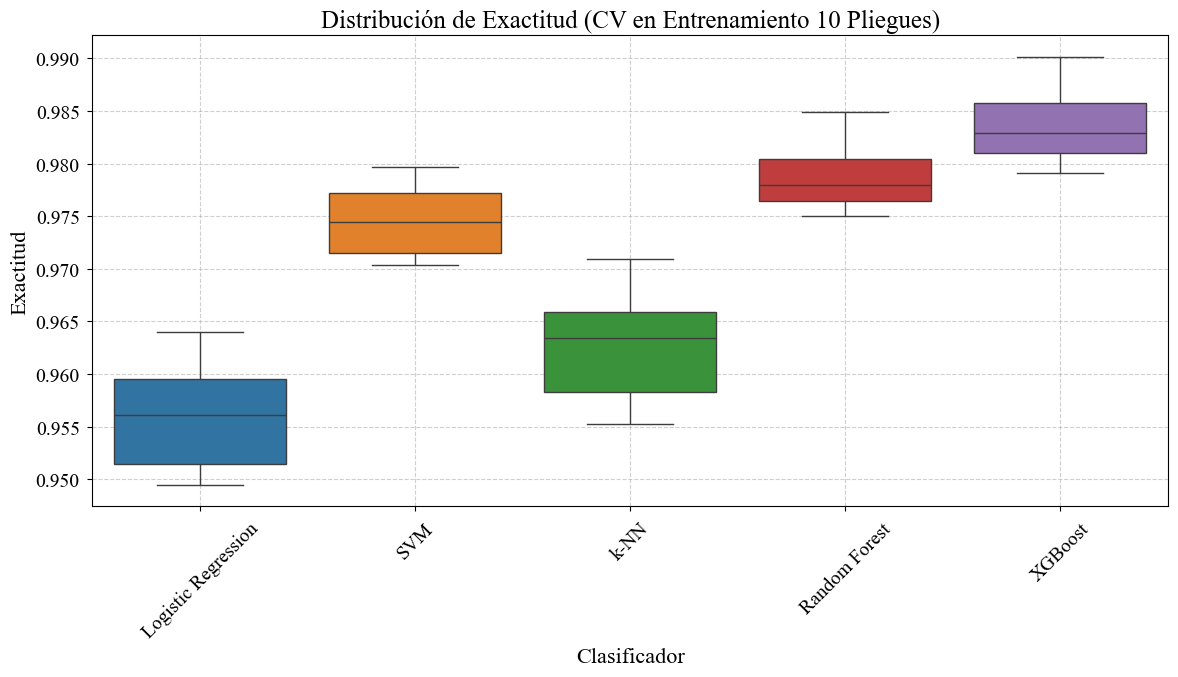

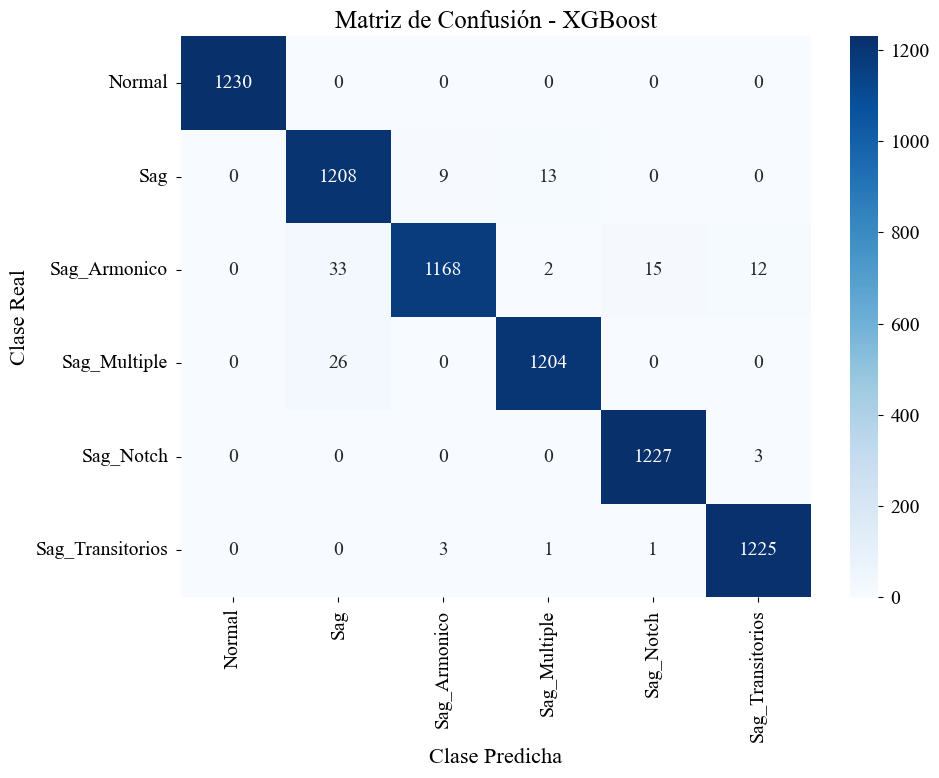

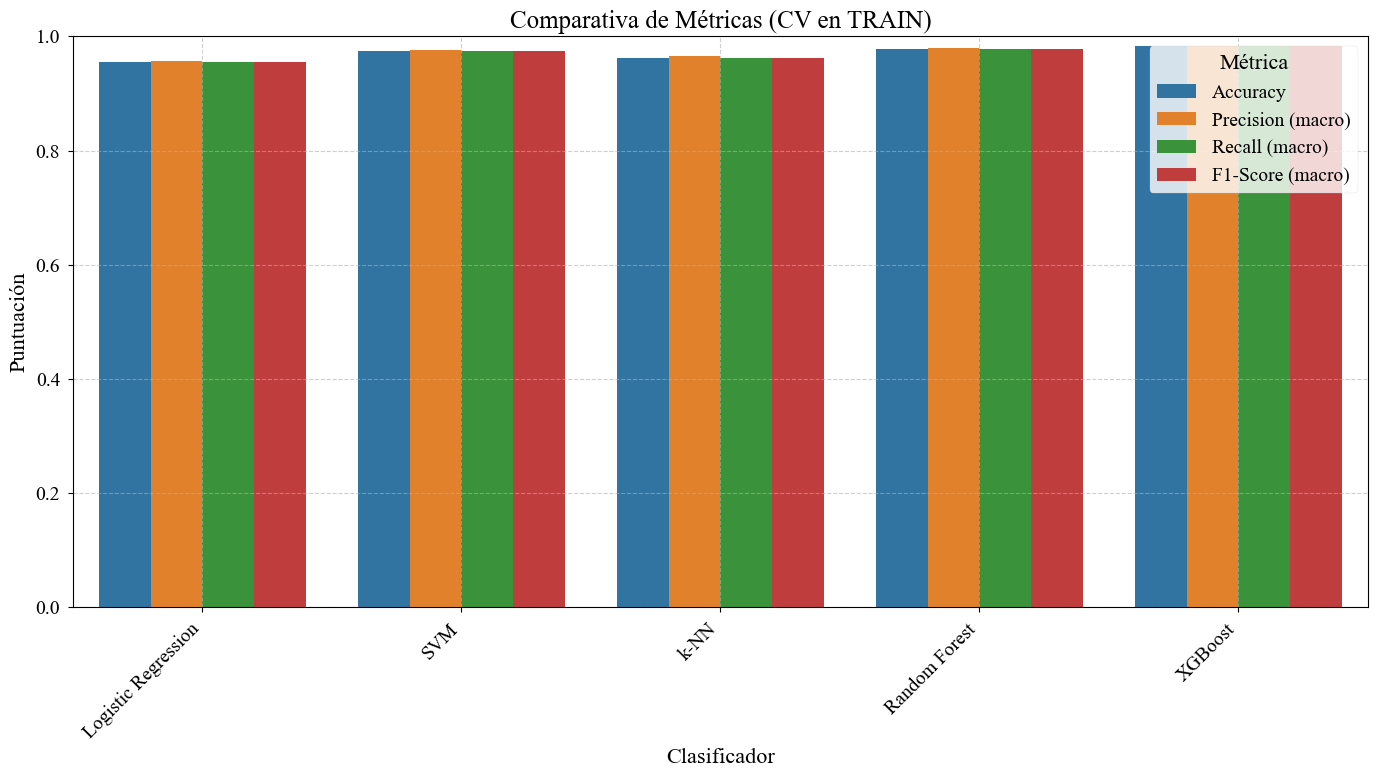

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_predict, cross_val_score, cross_validate)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# ---------- Estilo opcional ----------
def _setup_academic_style():
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix', 'font.size': 14,
        'axes.labelsize': 16, 'axes.titlesize': 18,
        'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 14, 'figure.figsize': (10, 6),
        'lines.linewidth': 2
    })

# ---------- Carga ----------
data_path = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv'
df = pd.read_csv(data_path)
X = df.drop(columns=['etiqueta', 'columna_origen', 'duracion_muestras'])
y = df['etiqueta']

le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

# ---------- Split primero (evita mirar el test durante selección) ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# ---------- Pipelines (sin fuga: scaler dentro) ----------
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
    ]),
    "k-NN": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ]),
    "Random Forest": Pipeline([
        ('scaler', 'passthrough'),
        ('clf', RandomForestClassifier(
            n_estimators=50, class_weight='balanced_subsample', random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', 'passthrough'),
        ('clf', xgb.XGBClassifier(
            objective='multi:softprob',
            eval_metric='mlogloss',
            num_class=len(np.unique(y_enc)),
            tree_method='hist',
            n_estimators=50,
            random_state=42))
    ])
}

# ---------- Comparativa por CV en TRAIN ----------
_setup_academic_style()
scoring = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted']

print("\n--- Comparativa (solo TRAIN con CV) ---")
results_rows = []
all_accuracies = {}
for name, pipe in models.items():
    # Predicciones CV para reportes macro en TRAIN
    y_pred_cv = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1)
    report = classification_report(y_train, y_pred_cv, output_dict=True)
    acc = accuracy_score(y_train, y_pred_cv)

    # Guardar fila resumen
    results_rows.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1-Score (macro)': report['macro avg']['f1-score']
    })

    # Distribución de accuracy por fold (para boxplot)
    accs = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    all_accuracies[name] = accs

    print(f"\n[{name}]")
    print(f"Accuracy (CV train): {acc:.4f}")
    print(classification_report(y_train, y_pred_cv, target_names=le.classes_))

results_df = pd.DataFrame(results_rows)
print("\n--- Tabla Resumen (TRAIN CV) ---")
print(results_df.to_string(index=False))

# ---------- Elegir mejor por F1 macro ----------
best_model_name = results_df.sort_values(by='F1-Score (macro)', ascending=False).iloc[0]['Model']
best_pipe = models[best_model_name]

# ---------- Ajuste final en TRAIN y evaluación en TEST ----------
best_pipe.fit(X_train, y_train)
y_test_pred = best_pipe.predict(X_test)

print(f"\n=== Evaluación en TEST con el mejor modelo: {best_model_name} ===")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# ---------- Visualizaciones ----------
# 1) Boxplot accuracies CV (TRAIN)
plt.figure(figsize=(12, 7))
sns.boxplot(data=pd.DataFrame(all_accuracies))
plt.title('Distribución de Exactitud (CV en Entrenamiento 10 Pliegues)')
plt.ylabel('Exactitud')
plt.xlabel('Clasificador')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Validación_Cruzada.svg")
plt.show()

# 2) Matriz de confusión en TEST
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.savefig("Matriz_Confusón_Mono.svg")
plt.show()

# 3) Barras de métricas (CV en TRAIN)
metrics_to_plot = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_to_plot)
plt.title('Comparativa de Métricas (CV en TRAIN)')
plt.ylabel('Puntuación')
plt.xlabel('Clasificador')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.0, 1.0)
plt.legend(title='Métrica')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [8]:
import joblib

# ---------- Ajuste final en TRAIN y evaluación en TEST ----------
best_pipe.fit(X_train, y_train)
y_test_pred = best_pipe.predict(X_test)

print(f"\n=== Evaluación en TEST con el mejor modelo: {best_model_name} ===")
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Asegúrate de que el mejor modelo es el que quieres guardar
if best_model_name == "XGBoost":
    joblib.dump(best_pipe, 'modelo_xgboost.joblib')
    joblib.dump(le, 'label_encoder.joblib')
    joblib.dump(X_train.columns, 'model_columns.joblib')

    print("\n¡Modelo XGBoost, LabelEncoder y columnas del modelo guardados exitosamente!")



=== Evaluación en TEST con el mejor modelo: XGBoost ===
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00      1230
             Sag       0.95      0.98      0.97      1230
    Sag_Armonico       0.99      0.95      0.97      1230
    Sag_Multiple       0.99      0.98      0.98      1230
       Sag_Notch       0.99      1.00      0.99      1230
Sag_Transitorios       0.99      1.00      0.99      1230

        accuracy                           0.98      7380
       macro avg       0.98      0.98      0.98      7380
    weighted avg       0.98      0.98      0.98      7380


¡Modelo XGBoost, LabelEncoder y columnas del modelo guardados exitosamente!


Cargando el dataset de características...
Se encontraron 6 clases: ['Normal' 'Sag' 'Sag_Armonico' 'Sag_Multiple' 'Sag_Notch'
 'Sag_Transitorios']

Seleccionando y escalando características numéricas (para t-SNE)...
ADVERTENCIA: Se descartaron las siguientes columnas no numéricas: ['columna_origen']
Se escalarán 20 características numéricas.

Calculando la proyección t-SNE... (esto puede tardar)
Proyección t-SNE calculada. Forma: (24600, 2)
Las imágenes se guardarán en la carpeta: fronteras_de_decision

Iniciando el entrenamiento y graficación de los modelos 2D...
Entrenando y graficando Logistic Regression...
Guardando gráfico en: fronteras_de_decision\frontera_decision_Logistic_Regression.png


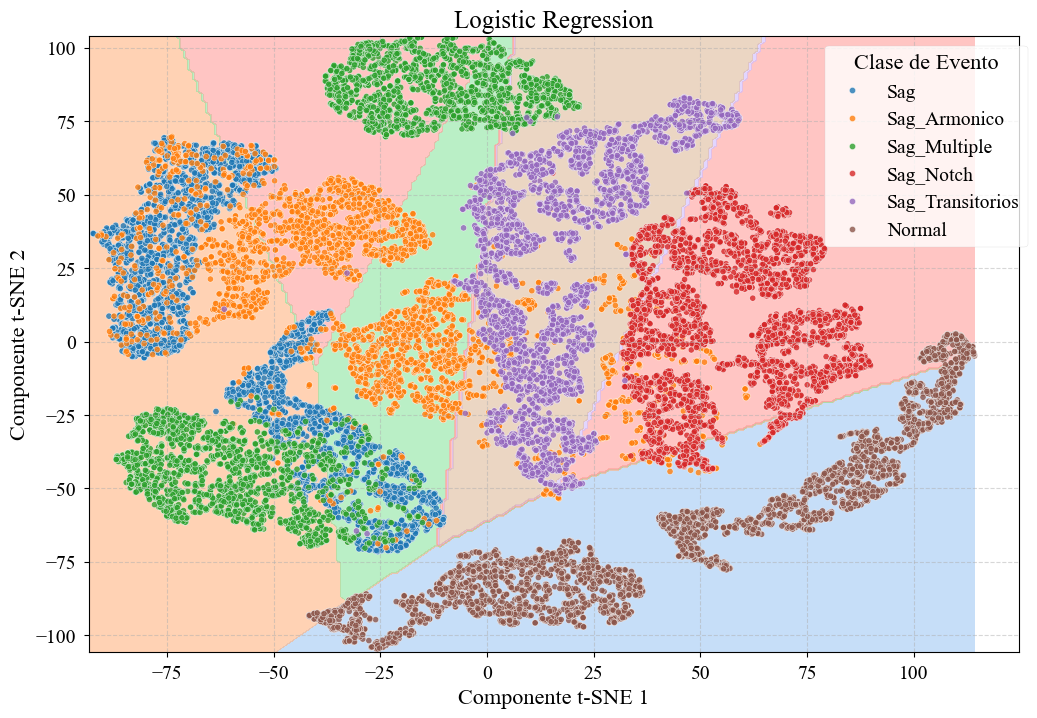

Entrenando y graficando SVM...
Guardando gráfico en: fronteras_de_decision\frontera_decision_SVM.png


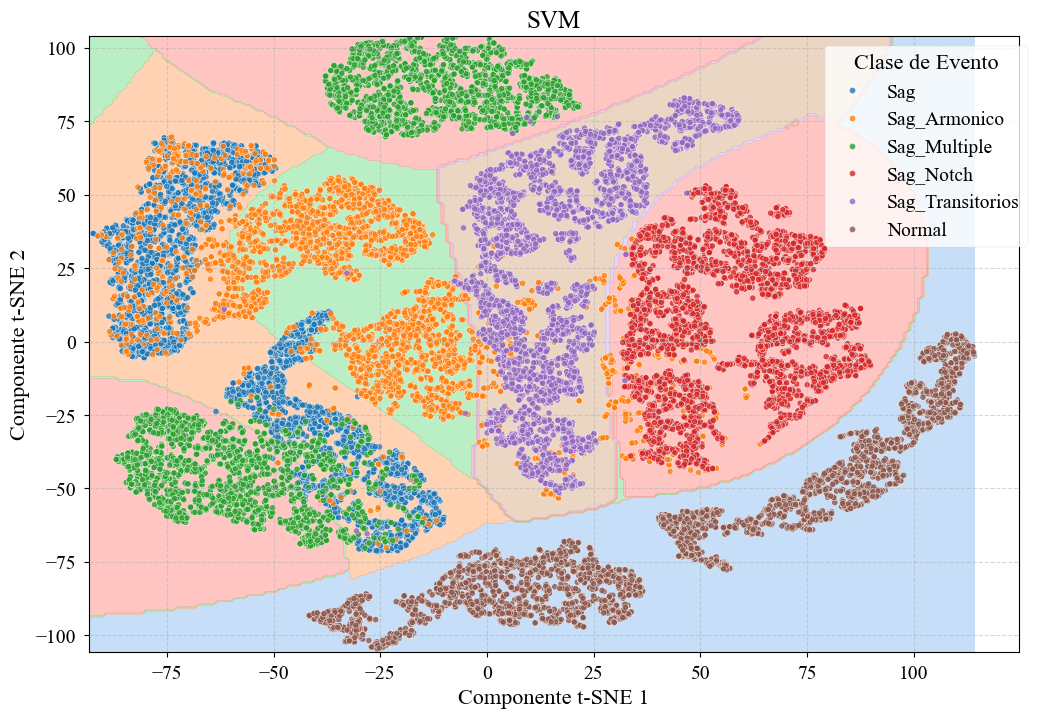

Entrenando y graficando k-NN...
Guardando gráfico en: fronteras_de_decision\frontera_decision_k_NN.png


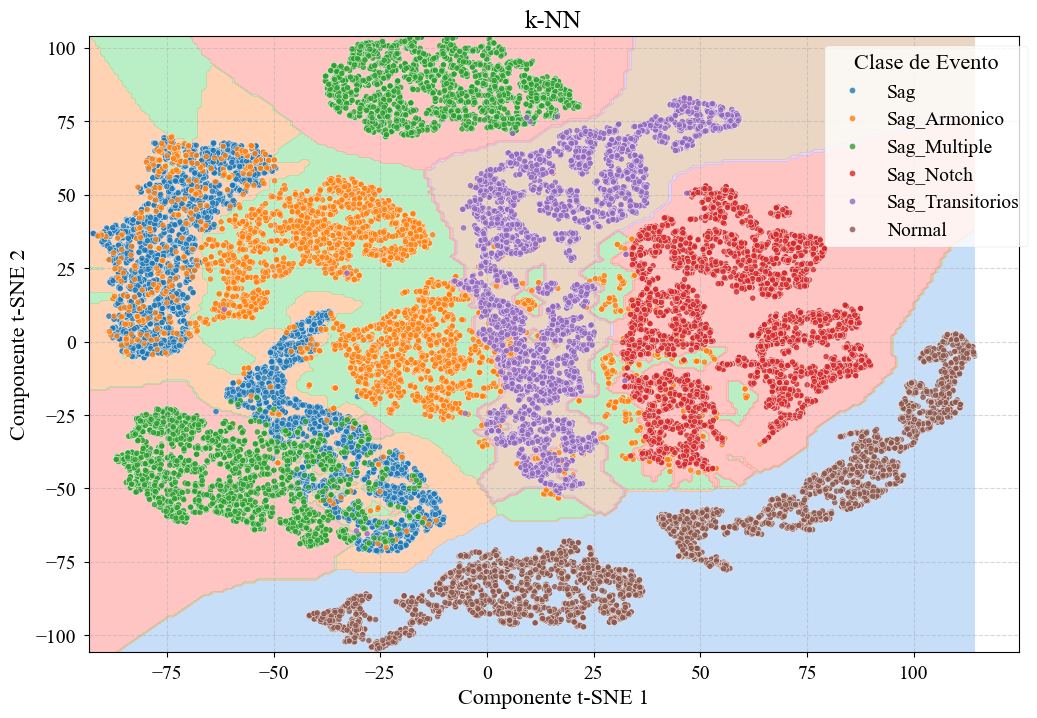

Entrenando y graficando Random Forest...
Guardando gráfico en: fronteras_de_decision\frontera_decision_Random_Forest.png


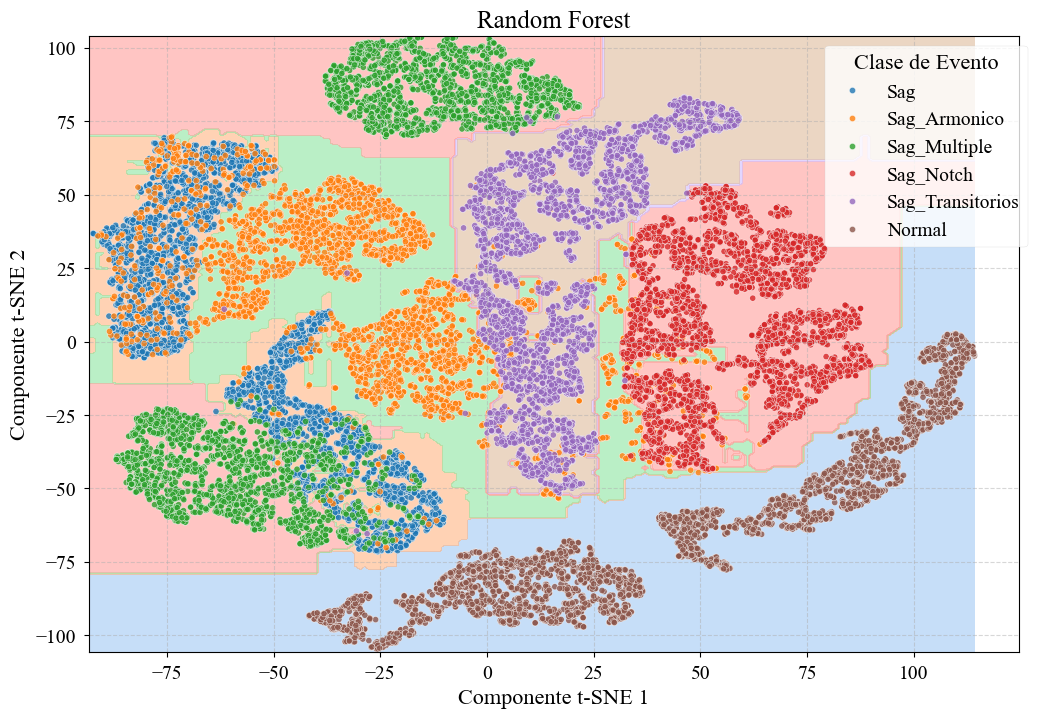

Entrenando y graficando XGBoost...


c:\Users\Juan_Saa\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:34:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Guardando gráfico en: fronteras_de_decision\frontera_decision_XGBoost.png


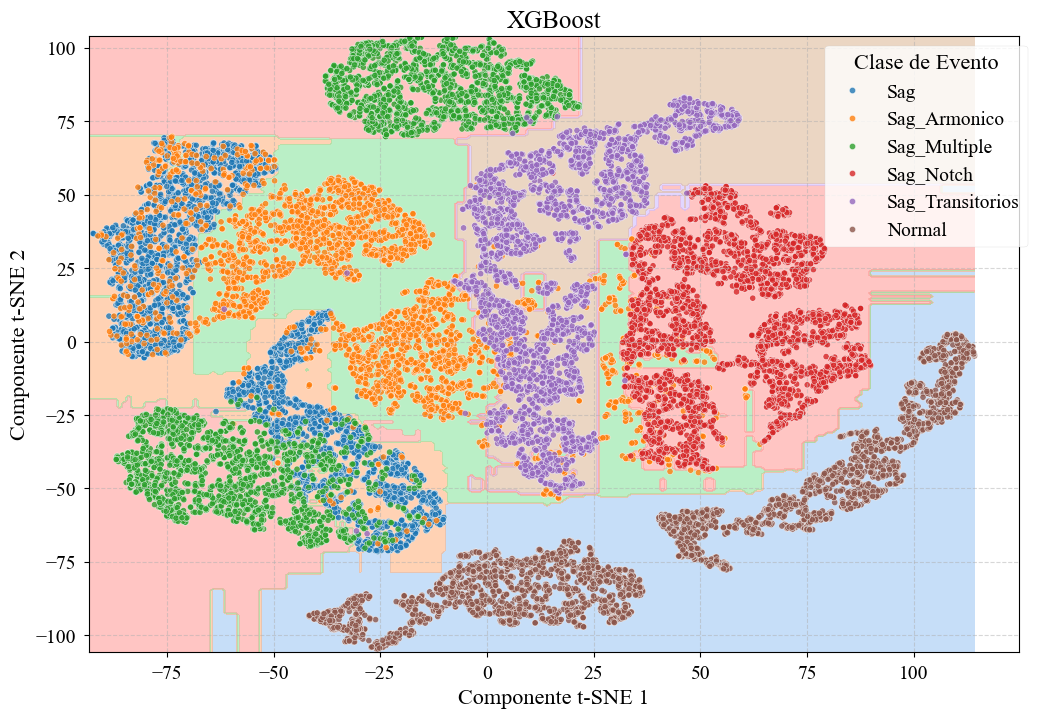


¡Todos los gráficos individuales han sido generados y guardados!
RECUERDA: Estas fronteras son de modelos 2D, no de tus modelos 19D.


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import warnings

# --- Importación de todos los modelos ---
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# --- 1. Cargar y preparar los datos ---
print("Cargando el dataset de características...")
data_path = r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Caracteristicas\Dataset_Final_Generado\Dataset_Caracteristicas_Final.csv"
df = pd.read_csv(data_path)

X_original = df.drop('etiqueta', axis=1)
y_texto = df['etiqueta'] # Etiquetas de texto para las leyendas

# Codificar etiquetas a números
le = LabelEncoder()
y_enc = le.fit_transform(y_texto)
class_names = le.classes_
print(f"Se encontraron {len(class_names)} clases: {class_names}")

# --- 2. Escalar las características (CORREGIDO) ---
print("\nSeleccionando y escalando características numéricas (para t-SNE)...")

# --- !! INICIO DE LA CORRECCIÓN ---
# Filtramos X para quedarnos únicamente con las columnas de tipo 'number'
X_numeric = X_original.select_dtypes(include=np.number)

# Informar al usuario qué columnas (si las hay) se descartaron
non_numeric_cols = X_original.select_dtypes(exclude=np.number).columns.tolist()
if non_numeric_cols:
    print(f"ADVERTENCIA: Se descartaron las siguientes columnas no numéricas: {non_numeric_cols}")

print(f"Se escalarán {X_numeric.shape[1]} características numéricas.")
scaler_19D = StandardScaler()
# Ahora escalamos SOLAMENTE el DataFrame numérico (X_numeric)
X_scaled_19D = scaler_19D.fit_transform(X_numeric) 
# --- FIN DE LA CORRECCIÓN ---

# --- 3. Cálculo de t-SNE ---
print("\nCalculando la proyección t-SNE... (esto puede tardar)")
# Ignorar advertencias futuras de scikit-learn sobre 'auto'
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, 
            init='pca', learning_rate='auto', max_iter=1000)
# Usamos los datos escalados para calcular la proyección 2D
X_2D = tsne.fit_transform(X_scaled_19D)

print("Proyección t-SNE calculada. Forma:", X_2D.shape)

# Crear una carpeta para guardar las imágenes
output_dir = "fronteras_de_decision"
os.makedirs(output_dir, exist_ok=True)
print(f"Las imágenes se guardarán en la carpeta: {output_dir}")

# --- 4. Definir los modelos (Pipelines) ---
# Nombres de modelo actualizados para ser más limpios
models_2D = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42))
    ]),
    "k-NN": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    "Random Forest": Pipeline([
        ('scaler', 'passthrough'), 
        ('clf', RandomForestClassifier(n_estimators=50, class_weight='balanced_subsample', random_state=42))
    ]),
    "XGBoost": Pipeline([
        ('scaler', 'passthrough'), 
        ('clf', xgb.XGBClassifier(
            objective='multi:softprob', eval_metric='mlogloss',
            num_class=len(class_names), tree_method='hist',
            n_estimators=50, use_label_encoder=False, random_state=42
        ))
    ])
}

# --- 5. Función para graficar las fronteras ---

def plot_decision_boundary(clf, X, y_num, y_txt, ax, title):
    """
    Función para graficar la frontera de decisión y los puntos.
    Incluye y formatea la leyenda.
    """
    
    # Crear un colormap para el fondo y los puntos
    n_classes = len(np.unique(y_num))
    cmap_light = ListedColormap(sns.color_palette("pastel", n_classes))
    cmap_bold = sns.color_palette("tab10", n_classes)
    
    # Definir los límites del gráfico
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Crear la "malla" (meshgrid) para el fondo
    # Ajustar 'h' para balancear velocidad y resolución
    h = (x_max - x_min) / 200  # Resolución media
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predecir la clase para cada punto de la malla
    # Silenciar advertencia de features en XGBoost (espera nombres)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Graficar el fondo (la frontera de decisión)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    
    # Graficar los puntos de datos (el scatter plot)
    sns.scatterplot(
        x=X[:, 0], y=X[:, 1],
        hue=y_txt, # Usar las etiquetas de texto para la leyenda
        palette=cmap_bold,
        alpha=0.8, s=20,
        ax=ax,
        legend="full"
    )
    
    # Formatear la leyenda para artículo
    legend = ax.get_legend()
    legend.set_title('Clase de Evento')
    legend.set_bbox_to_anchor((1.02, 1)) # Moverla fuera del gráfico
    legend.loc = 'upper left'
    
    # Título del gráfico (solo el nombre del modelo)
    ax.set_title(title)
    ax.set_xlabel('Componente t-SNE 1')
    ax.set_ylabel('Componente t-SNE 2')
    ax.grid(True, linestyle='--', alpha=0.5)

# --- 6. Entrenar y Graficar cada modelo ---
print("\nIniciando el entrenamiento y graficación de los modelos 2D...")

# Configurar el estilo académico
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 'font.size': 14,
    'axes.labelsize': 16, 'axes.titlesize': 18,
    'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'legend.title_fontsize': 16,
    'figure.figsize': (12, 8)
})

# Bucle para gráficos individuales
for name, model in models_2D.items():
    print(f"Entrenando y graficando {name}...")
    
    # 1. Crear una NUEVA figura y ejes para CADA modelo
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # 2. Entrenar el modelo 2D
    model.fit(X_2D, y_enc)
    
    # 3. Graficar
    plot_decision_boundary(model, X_2D, y_enc, y_texto, ax, name)
    
    # 5. Guardar la figura individual
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
    save_filename = os.path.join(output_dir, f"frontera_decision_{safe_name}.png")
    print(f"Guardando gráfico en: {save_filename}")
    
    # bbox_inches='tight' es CRUCIAL para guardar la leyenda externa
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    
    # 6. Mostrar el gráfico
    plt.show()
    
    # 7. Cerrar la figura para liberar memoria
    plt.close(fig)

print("\n¡Todos los gráficos individuales han sido generados y guardados!")
print("RECUERDA: Estas fronteras son de modelos 2D, no de tus modelos 19D.")